# Mesh Generation with FloPy

This notebook shows you how to build the grid types MODFLOW 6 can use, all from the same watershed dataset, using FloPy's mesh-generation utilities. By the end you will be able to turn a raster and a few shapefiles into a structured grid, refine it locally, and generate fully flexible (unstructured) grids for a MODFLOW 6 model.

MODFLOW 6 supports three discretization (grid) types, and each grid you build below feeds one of them:

   - **DIS** — a structured, row-and-column grid. Simple and fast, but cell size is tied to whole rows and columns.
   - **DISV** — discretization by vertices. Cells are polygons defined by a list of vertices, so you can refine only where you need detail. Quadtree, triangular, and Voronoi grids all feed DISV.
   - **DISU** — fully unstructured discretization, where each cell lists its own neighbors. The most flexible option, used when the connections between cells cannot be described by shared vertices alone.

You will build and compare these grids:

   - **Structured Grid**: a regular rectilinear grid; the starting point for everything else (feeds DIS).
   - **Local Grid Refinement (LGR)**: a finer rectilinear grid embedded in a coarser one as a separate, coupled model. Good for extra detail in a compact rectangular area.
   - **Quadtree Mesh**: a rectilinear grid whose cells are recursively split into four, grading smoothly toward a feature. Good for graded refinement around lines or points (feeds DISV).
   - **Triangular Mesh**: a mesh of triangles from a Delaunay triangulation. Good for fitting irregular boundaries and refining along channels (feeds DISV).
   - **Voronoi Mesh**: polygonal cells built from the centers of the Delaunay triangulation circumcircles. Good for smooth, well-shaped cells whose connections meet their shared faces at right angles (feeds DISV).

All inputs use a consistent length unit of meters and the projected coordinate system EPSG:26911 (UTM zone 11N).


In [ ]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from flopy.discretization import StructuredGrid, VertexGrid
from flopy.plot import PlotMapView
from flopy.utils.gridgen import Gridgen
from flopy.utils.gridintersect import GridIntersect
from flopy.utils.lgrutil import Lgr
from flopy.utils.rasters import Raster
from flopy.utils.triangle import Triangle
from flopy.utils.voronoi import VoronoiGrid

warnings.simplefilter("ignore", DeprecationWarning)

## Creating a structured (rectilinear) grid

Start by building a **structured (rectilinear) grid** — the regular row-and-column grid used by the DIS package and the foundation the other meshes are built from. Derive it from a 1/3 arc-second **Digital Elevation Model (DEM)** of the Sagehen Creek watershed, which gives you a real domain to discretize and land-surface elevations to drape over the grid.

The workflow is: load the DEM, read its extent, choose a cell size, and assemble a FloPy `StructuredGrid` object that later steps resample and clip data onto.

Load the Digital Elevation Model and visualize it

In [ ]:
dem = Path("../data/sagehen_geospatial/dem.img")
rstr = Raster.load(dem)
rstr.plot();

Get the DEM boundaries

In [ ]:
xmin, xmax, ymin, ymax = rstr.bounds
print(xmin, xmax)

And begin developing an initial mesh for the model

In [ ]:
dx = dy = 100
lx = xmax - xmin
ly = ymax - ymin
nlay = 1
nrow = int(np.floor(ly / dy))
ncol = int(np.floor(lx / dx))
delc = np.full((nrow,), dx)
delr = np.full((ncol,), dy)

Finally create a fake top, bottom, and idomain for the model for now. These will be updated in a subsequent step.

In [ ]:
top = np.ones((nrow, ncol))
botm = np.zeros((nlay, nrow, ncol))
idomain = np.ones((nlay, nrow, ncol), dtype=int)

And now we can generate a `StructuredGrid` object that can be used for developing model inputs

In [ ]:
# live code
crs = "EPSG:26911"
sgrid = StructuredGrid()

We can plot our `SturcturedGrid` object over the existing raster data to check that it is correctly oriented in space

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
rstr.plot(ax=ax)
pmv = PlotMapView(modelgrid=sgrid, ax=ax)
pmv.plot_grid(lw=0.5);

**What to look for.** The black grid lines should sit squarely on top of the DEM with no offset or rotation, confirming the `StructuredGrid` is georeferenced correctly. Every cell is the same 100 m square, and the grid blankets the full raster extent — uniform everywhere, with no refinement yet.

### Resample data onto the grid

With an initial grid in hand, resample raster data and intersect vector data onto it to turn the empty grid into a model domain. The focus of this notebook is mesh generation, but the same resampling and intersection steps shown here apply to many data types and are how you build boundary conditions in a MODFLOW model.

#### Resample the DEM to the grid (top elevation)

Set the land-surface elevation (`top`) on each cell by resampling the DEM onto the `StructuredGrid`. Call `rstr.resample_to_grid()` with the target grid, the raster band, and a `method` (here `"min"`, the lowest DEM value in each cell). For more resampling options, see this [raster resampling example](https://flopy.readthedocs.io/en/latest/Notebooks/raster_intersection_example.html).

In [ ]:
top = rstr.resample_to_grid(sgrid, rstr.bands[0], method="min", extrapolate_edges=True)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
pmv = PlotMapView(modelgrid=sgrid)
pc = pmv.plot_array(top)
pmv.plot_grid(lw=0.5)
plt.colorbar(pc, shrink=0.7);

#### Intersect a shapefile with the grid (active area)

Intersect lines, points, and polygons with the grid using FloPy's `GridIntersect`, which reports the cell IDs each feature touches. Here you load the watershed-boundary polygon and use the returned cells to mark which cells are active (inside the watershed) versus inactive. For more, see this [grid intersection example](https://flopy.readthedocs.io/en/latest/Notebooks/grid_intersection_example.html).

In [ ]:
watershed = Path("../data/sagehen_geospatial/watershed_boundary.shp")
gdf = gpd.read_file(watershed)

fig, ax = plt.subplots(figsize=(5, 5))
gdf.plot(ax=ax);

Doing the intersection

In [ ]:
ix = GridIntersect(sgrid)
result = ix.intersect(gdf.geometry.values[0], contains_centroid=True)
rowcol = result["cellids"]
rowcol

In [ ]:
row, col = list(zip(*rowcol))

Building idomain from the intersection

In [ ]:
idomain = np.zeros((nlay, nrow, ncol), dtype=int)
idomain[:, row, col] = 1

Putting it all together into a `StructuredGrid`

In [ ]:
sgrid = StructuredGrid(
    delc=sgrid.delc,
    delr=sgrid.delr,
    top=top,
    botm=sgrid.botm,
    idomain=idomain,
    nlay=sgrid.nlay,
    nrow=sgrid.nrow,
    ncol=sgrid.ncol,
    xoff=sgrid.xoffset,
    yoff=sgrid.yoffset,
    crs=sgrid.crs,
)
sgrid

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
pmv = PlotMapView(modelgrid=sgrid)
pc = pmv.plot_array(sgrid.top)
ib = pmv.plot_inactive()
pmv.plot_grid(lw=0.5)
plt.colorbar(pc, shrink=0.7);

Because this is a watershed, we can also overlay a shapefile of the streams and get the stream cells using `GridIntersect`

In [ ]:
streams = Path("../data/sagehen_geospatial/streams.shp")
stgdf = gpd.read_file(streams)
stgdf.head()

In [ ]:
rowcols = []
ix = GridIntersect(sgrid)
for geom in stgdf.geometry.values:
    rcs = ix.intersects(geom)["cellids"]
    rowcols.extend(list(rcs))

In [ ]:
row, col = list(zip(*rowcols))
strms = np.zeros((nrow, ncol))
strms[row, col] = 1
strms

Plot the intersection results

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
pmv = PlotMapView(modelgrid=sgrid, ax=ax)
pc = pmv.plot_array(sgrid.top, cmap="viridis")
pmv.plot_array(
    strms,
    masked_values=[
        0,
    ],
    alpha=0.3,
    cmap="Reds_r",
)
pmv.plot_inactive()
pmv.plot_grid(lw=0.5)
stgdf.plot(ax=ax)
plt.colorbar(pc, shrink=0.7);

**What to look for.** The colored area is the active watershed (cells inside the boundary polygon); the surrounding inactive cells are masked out. The red stream cells trace the channel network and should line up with the blue stream shapefile plotted on top — a good check that the intersection put the streams in the right cells. These stream cells are the feature you refine around in the meshes that follow.

Information from the grid we've created here can now be used for generating more complex meshes.

## Local Grid Refinement (LGR) mesh

Build a **Local Grid Refinement (LGR)** grid when you want finer detail in one compact area without refining the whole model. LGR embeds a finer rectilinear child grid inside the coarser parent grid as a *separate* model; the two are run together in one MODFLOW 6 simulation and exchange flow across their shared boundary. Use FloPy's `Lgr` utility to build the refined child grid and compute those parent-child exchanges.

The `Lgr` utility has a number of input parameters:
   - `nlayp`: the number of parent model layers
   - `nrowp`: the number of parent model rows
   - `ncolp`: the number of parent model columns
   - `delrp`: the parent model delr array
   - `delcp`: the parent model delc array
   - `topp`: the parent model top array
   - `botmp`: the parent model botm array
   - `idomainp`: an idomain array that is used to create the child grid. Values of 1 indicate parent model cells, values of 0 indicate child model cells. The child model must be a rectangular region that is continuous.
   - `ncpp`: number of child cells along the face of a parent cell
   - `ncppl`: number of child cells per parent layer
   - `xllp`: (optional) x location of parent grid lower left corner
   - `yllp`: (optional) y-location of parent grid lower left corner

**Load up the refinement area polygon**

In [ ]:
lgr_poly = Path("../data/sagehen_geospatial/lgr_bound.shp")
lgr_gdf = gpd.read_file(lgr_poly)

Plot it to see if it lines up properly with our model

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
pmv = PlotMapView(modelgrid=sgrid, ax=ax)
pc = pmv.plot_array(sgrid.top, cmap="viridis")
pmv.plot_array(
    strms,
    masked_values=[
        0,
    ],
    alpha=0.3,
    cmap="Reds_r",
)
pmv.plot_inactive()
pmv.plot_grid(lw=0.5)
stgdf.plot(ax=ax)
lgr_gdf.plot(ax=ax, alpha=0.5)
plt.colorbar(pc, shrink=0.7);

Creating the parent/child idomainp array for `Lgr` using `GridIntersect`

In [ ]:
lgr_gdf

In [ ]:
idomainp = np.ones(sgrid.shape, dtype=int)

ix = GridIntersect(sgrid)
rowcol = ix.intersect(lgr_gdf.geometry.values[0], contains_centroid=True)["cellids"]
crow, ccol = list(zip(*rowcol))
idomainp[:, crow, ccol] = 0

Creating the `Lgr` object/child grid

In [ ]:
lgr = Lgr(
    nlayp=sgrid.nlay,
    nrowp=sgrid.nrow,
    ncolp=sgrid.ncol,
    delrp=sgrid.delr,
    delcp=sgrid.delc,
    topp=sgrid.top,
    botmp=sgrid.botm,
    idomainp=idomainp,
    ncpp=4,
    xllp=sgrid.xoffset,
    yllp=sgrid.yoffset,
)

Get a `StructuredGrid` of the child model

In [ ]:
childgrid = lgr.child.modelgrid
childgrid

Resample top elevations to the child grid

In [ ]:
childtop = rstr.resample_to_grid(childgrid, band=rstr.bands[0], method="min")
print(childtop.shape)
print(childgrid.shape)

Reset the top elevations in the `childgrid` object

In [ ]:
childgrid._top = childtop

Intersect streams with the Child mesh to define stream cells

In [ ]:
ix = GridIntersect(childgrid)
cstrmcells = []
for geom in stgdf.geometry.values:
    rcs = ix.intersects(geom)["cellids"]
    if len(rowcol) > 0:
        cstrmcells.extend(list(rcs))

cstrms = np.zeros((childgrid.nrow, childgrid.ncol), dtype=int)
row, col = list(zip(*cstrmcells))
cstrms[row, col] = 1

And now we can visualize the new LGR mesh

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
vmin, vmax = np.min(sgrid.top), np.max(sgrid.top)

pmvp = PlotMapView(modelgrid=sgrid, ax=ax)
ptop = sgrid.top.copy()
ptop[crow, ccol] = np.nan
pstrms = strms.copy()
pstrms[crow, ccol] = np.nan
pc = pmvp.plot_array(ptop, cmap="viridis", vmin=vmin, vmax=vmax)
pmvp.plot_array(
    pstrms,
    masked_values=[
        0,
    ],
    alpha=0.3,
    cmap="Reds_r",
)
pmvp.plot_inactive()
pmvp.plot_grid(lw=0.3)
stgdf.plot(ax=ax)

pmvc = PlotMapView(modelgrid=childgrid, ax=ax, extent=sgrid.extent)
pmvc.plot_array(childtop, cmap="viridis", vmin=vmin, vmax=vmax)
pmvc.plot_array(
    cstrms,
    masked_values=[
        0,
    ],
    alpha=0.3,
    cmap="Reds_r",
)
pmvc.plot_grid(lw=0.3)
plt.colorbar(pc, shrink=0.7);

**What to look for.** The coarse parent grid covers the watershed, and inside the refinement polygon the cells switch to the finer child grid (here four child cells along each parent cell face). The child grid resolves the stream and topography in more detail while the parent stays coarse elsewhere. Note the clean, abrupt rectangular boundary between parent and child — LGR refinement is always a rectangular block.

## Quadtree Mesh

Build a **quadtree** grid to refine a rectilinear grid smoothly toward a feature. A quadtree is an unstructured refinement of a structured grid: each cell you refine is split into four child cells, and this can repeat recursively for finer and finer detail. Unlike LGR, the refinement follows the feature and grades from coarse to fine, and the whole thing becomes a single vertex grid (DISV) rather than a separate coupled model.

The figure below is from [Lien and others, 2019](https://pubs.usgs.gov/of/2014/1109/pdf/ofr2014-1109.pdf) and shows multiple levels of recursive refinement.

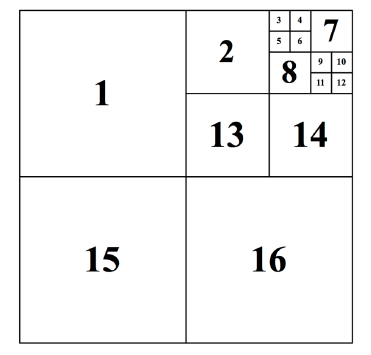

Use GRIDGEN, through FloPy's `Gridgen` utility, to build the quadtree refinement around the stream channels in this example.

In [ ]:
gridgen_dir = Path("models/sagehen_gridgen")
gridgen_dir.mkdir(exist_ok=True)

The `Gridgen` class a number of input parameters and further documentation/examples of the class can be found [here](https://flopy.readthedocs.io/en/latest/Notebooks/gridgen_example.html). For our example, we will be refining the area around the stream channels.

In [ ]:
g = Gridgen(sgrid, model_ws=gridgen_dir)
for geom in stgdf.geometry.values:
    xy = list(zip(*geom.coords.xy))
    g.add_refinement_features(
        [
            xy,
        ],
        "line",
        2,
        range(1),
    )

In [ ]:
g.build()

After gridgen builds the mesh, it can be used to create a `VertexGrid` (or DISV) that represents the basin

In [ ]:
gridprops = g.get_gridprops_disv()
gridprops.pop("nvert")

quadgrid = VertexGrid(**gridprops)
quadgrid.extent

Resample top elevations to the quadtree mesh and intersect the basin boundary and stream vectors

In [ ]:
# create the top array
top = rstr.resample_to_grid(quadgrid, band=rstr.bands[0], method="min")
quadgrid._top = top

In [ ]:
# create the idomain array
idomain = np.zeros(quadgrid.shape, dtype=int)
ix = GridIntersect(quadgrid)
nodes = ix.intersect(gdf.geometry.values[0], contains_centroid=True)["cellids"]
idomain[:, list(nodes)] = 1
quadgrid._idomain = idomain

In [ ]:
# create an array of stream cells
qstr = []
ix = GridIntersect(quadgrid)
for geom in stgdf.geometry.values:
    nodes = ix.intersects(geom)["cellids"]
    qstr.extend(list(nodes))

In [ ]:
qstrms = np.zeros((quadgrid.ncpl,), dtype=int)
qstrms[qstr] = 1

Plot the quadtree mesh with top elevations and streams

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

pmv = PlotMapView(modelgrid=quadgrid)
pc = pmv.plot_array(quadgrid.top)
pmv.plot_array(
    qstrms,
    masked_values=[
        0,
    ],
    alpha=0.8,
    cmap="Reds_r",
)
pmv.plot_inactive()
pmv.plot_grid(lw=0.3)
# stgdf.plot(ax=ax)
plt.colorbar(pc, shrink=0.7);

**What to look for.** The grid is coarse across most of the watershed but steps down to smaller cells along the stream network, where you asked Gridgen to refine. Each refinement level quarters a cell, so you should see cells grading to finer resolution as they approach the channels. The refined cells stay square — quadtree refinement keeps right angles — which keeps the cell geometry clean for the flow solution.

## Triangular Mesh

Build a **triangular** grid when you want cells that fit irregular boundaries and refine flexibly along features. A triangular mesh is a vertex grid (DISV) of triangles produced by Delaunay triangulation, generated by the "triangle" program ([Shewchuk, 2002](https://www.sciencedirect.com/science/article/pii/S0925772101000475)) and driven through FloPy's `Triangle` utility.

Here you will triangulate the watershed and add finer triangles around the streams.

In [ ]:
tri_dir = Path("models/sagehen_tri")
tri_dir.mkdir(exist_ok=True)

For this example, we will use the watershed boundary and create a dissovled polygon of stream segments to generate our triangulation regions.

Start by creating a geodataframe of the active watershed area defined by our `StructuredGrid`

In [ ]:
sgdf = sgrid.geo_dataframe
sgdf.head()

Filter the geodataframe for only active cells (idomain > 0)

In [ ]:
sgdf["idomain"] = sgrid.idomain[0].ravel()
sgdf = sgdf[sgdf.idomain > 0]
sgdf.head()

And dissolve the active area into a single polygon

In [ ]:
sgdf = sgdf.dissolve()
sgdf.plot();

Now to dissolve and buffer the stream network into a single polygon that defines our area of refinement

In [ ]:
bufgdf = stgdf.dissolve()
bufgdf["geometry"] = bufgdf.geometry.buffer(50, cap_style=2, join_style=3)
bufgdf.plot();

These two polygons can now be used to generate a triangular mesh with the `Triangle` utility. The `Triangle` class has a number of input parameters. For more detail on the inputs and additional examples please see this [notebook](https://flopy.readthedocs.io/en/latest/Notebooks/dis_voronoi_example.html)

In [ ]:
# define point locations within the watershed and the stream for adding regions
wsloc = (220000, 4368000)
stloc = (219250, 4370000)

In [ ]:
tri = Triangle(angle=30, model_ws=tri_dir)

# define the model/mesh boundary
tri.add_polygon(sgdf.geometry.values[0])
tri.add_region(wsloc, 0, maximum_area=100 * 300)

# define the stream refinement area
tri.add_polygon(bufgdf.geometry.values[0])
tri.add_region(stloc, 1, maximum_area=40 * 40)

In [ ]:
tri.build()

Visualize the triangular mesh

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
tri.plot(ax=ax)
stgdf.plot(ax=ax);

**What to look for.** The triangles are small and dense inside the buffered stream region and larger out in the rest of the watershed — the two `add_region` calls set different maximum triangle areas. Notice the triangles are well-shaped, with no long thin slivers; the `angle=30` constraint tells "triangle" to keep every corner angle at least 30 degrees, which matters for a stable, accurate flow solution.

Create a `VertexGrid` from the triangular mesh and resample the land surface elevations

In [ ]:
cell2d = tri.get_cell2d()
vertices = tri.get_vertices()
ncpl = len(cell2d)
nlay = 1
idomain = np.ones((nlay, ncpl), dtype=int)

# set fake values for top and botm for now)
top = np.ones((ncpl,))
botm = np.zeros((nlay, ncpl))

In [ ]:
trigrid = VertexGrid(
    vertices=vertices,
    cell2d=cell2d,
    ncpl=ncpl,
    nlay=nlay,
    idomain=idomain,
    top=top,
    botm=botm,
    crs="EPSG:26911",
)
trigrid.extent

In [ ]:
top = rstr.resample_to_grid(
    trigrid, band=rstr.bands[0], method="min", extrapolate_edges=True
)
trigrid._top = top

And perform intersection to identify stream cells

In [ ]:
tristr = []
ix = GridIntersect(trigrid)
for geom in stgdf.geometry.values:
    nodes = ix.intersects(geom)["cellids"]
    tristr.extend(list(nodes))

tristrms = np.zeros((trigrid.ncpl,), dtype=int)
tristrms[tristr] = 1

Now to plot up the triangular grid

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

pmv = PlotMapView(modelgrid=trigrid)
pc = pmv.plot_array(trigrid.top)
pmv.plot_array(
    tristrms,
    masked_values=[
        0,
    ],
    alpha=0.3,
    cmap="Reds_r",
)
pmv.plot_inactive()
pmv.plot_grid(lw=0.3)
stgdf.plot(ax=ax)
plt.colorbar(pc, shrink=0.7);

## Voronoi Mesh

Build a **Voronoi** grid when you want smooth, well-shaped polygonal cells. A Voronoi mesh is built from a Delaunay triangulation: the center of each triangle's circumcircle becomes a vertex, and connecting the centers of adjacent triangles forms polygonal cells. The result is a vertex grid (DISV) whose cell connections meet their shared faces at right angles — a desirable property for the finite-volume flow calculation.

FloPy's `VoronoiGrid` utility builds a Voronoi mesh directly from a triangulation. Reuse the `Triangle` object (`tri`) you built above. For more information and additional examples, see this [notebook](https://flopy.readthedocs.io/en/latest/Notebooks/dis_voronoi_example.html).

To generate a voronoi mesh, we just need to pass our triangluation object (`tri`) to the `VoronoiGrid` utility

In [ ]:
voronoi_obj = VoronoiGrid(tri)

Build a `VertexGrid`

In [ ]:
gridprops = voronoi_obj.get_gridprops_vertexgrid()
nlay = 1
idomain = np.ones(gridprops["ncpl"], dtype=int)
top = idomain.copy().astype(float)
botm = np.zeros((nlay, gridprops["ncpl"]))

In [ ]:
vorgrid = VertexGrid(nlay=nlay, idomain=idomain, top=top, botm=botm, **gridprops)

Resample the land surface elevation from the DEM to the voronoi grid

In [ ]:
top = rstr.resample_to_grid(
    vorgrid, band=rstr.bands[0], method="min", extrapolate_edges=True
)
vorgrid._top = top

Identify stream cells with `GridIntersect`

In [ ]:
vorst = []
ix = GridIntersect(vorgrid)
for geom in stgdf.geometry.values:
    nodes = ix.intersects(geom)["cellids"]
    vorst.extend(list(nodes))

vorstrms = np.zeros((vorgrid.ncpl,), dtype=int)
vorstrms[vorst] = 1

Finally plot the voronoi mesh with the DEM data and stream locations

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

pmv = PlotMapView(modelgrid=vorgrid)
pc = pmv.plot_array(vorgrid.top)
pmv.plot_array(
    vorstrms,
    masked_values=[
        0,
    ],
    alpha=0.8,
    cmap="Reds_r",
)
pmv.plot_inactive()
pmv.plot_grid(lw=0.3)
# stgdf.plot(ax=ax)
plt.colorbar(pc, shrink=0.7);

**What to look for.** The cells are polygons that inherit the triangulation's refinement — smaller near the streams, larger elsewhere — but with smoother, more uniform shapes than the raw triangles. Because each Voronoi cell wraps one triangulation point, the refined stream corridor stands out as a band of small cells threading through the coarser watershed.

Now we can plot all of the meshes we produced side by side for comparison!

In [ ]:
from flopy.plot import styles
from matplotlib.gridspec import GridSpec

with styles.USGSMap():
    fig = plt.figure(figsize=(8, 10))
    gs = GridSpec(14, 2, figure=fig)
    ax0 = fig.add_subplot(gs[0:4, 0])
    ax1 = fig.add_subplot(gs[0:4, 1])
    ax2 = fig.add_subplot(gs[5:9, 0])
    ax3 = fig.add_subplot(gs[5:9, 1])
    ax4 = fig.add_subplot(gs[10:, 0])
    ax5 = fig.add_subplot(
        gs[11, 1],
    )

    # structured grid
    pmv = PlotMapView(modelgrid=sgrid, ax=ax0)
    pmv.plot_array(sgrid.top, cmap="viridis")
    pmv.plot_array(
        strms,
        masked_values=[
            0,
        ],
        alpha=0.8,
        cmap="Reds_r",
    )
    pmv.plot_inactive()
    pmv.plot_grid(lw=0.3)
    stgdf.plot(ax=ax0)
    styles.heading(ax0, "A. ", heading="Structured Grid", x=0.10)

    # LGR grid
    pmvp = PlotMapView(modelgrid=sgrid, ax=ax1)
    ptop = sgrid.top.copy()
    ptop[crow, ccol] = np.nan
    pstrms[crow, ccol] = np.nan
    pc = pmvp.plot_array(ptop, cmap="viridis", vmin=vmin, vmax=vmax)
    pmvp.plot_array(
        pstrms,
        masked_values=[
            0,
        ],
        alpha=0.8,
        cmap="Reds_r",
    )
    pmvp.plot_inactive()
    pmvp.plot_grid(lw=0.3)
    stgdf.plot(ax=ax1)

    pmvc = PlotMapView(modelgrid=childgrid, ax=ax1)
    pmvc.plot_array(childtop, cmap="viridis", vmin=vmin, vmax=vmax)
    pmvc.plot_array(
        cstrms,
        masked_values=[
            0,
        ],
        alpha=0.8,
        cmap="Reds_r",
    )
    pmvc.plot_grid(lw=0.1)
    styles.heading(ax1, "B. ", heading="LGR Grid", x=0.10)

    # Quadtree grid
    pmv = PlotMapView(modelgrid=quadgrid, ax=ax2)
    pc = pmv.plot_array(quadgrid.top)
    pmv.plot_array(
        qstrms,
        masked_values=[
            0,
        ],
        alpha=0.8,
        cmap="Reds_r",
    )
    pmv.plot_inactive()
    pmv.plot_grid(lw=0.2)
    stgdf.plot(ax=ax2)
    styles.heading(ax2, "C. ", heading="Quadtree Grid", x=0.10)

    # Triangular grid
    pmv = PlotMapView(modelgrid=trigrid, ax=ax3)
    pc = pmv.plot_array(trigrid.top)
    pmv.plot_array(
        tristrms,
        masked_values=[
            0,
        ],
        alpha=0.8,
        cmap="Reds_r",
    )
    pmv.plot_inactive()
    pmv.plot_grid(lw=0.3)
    stgdf.plot(ax=ax3)
    styles.heading(ax3, "D. ", heading="Triangular Grid", x=0.10)

    # Voronoi grid
    pmv = PlotMapView(modelgrid=vorgrid, ax=ax4)
    pc = pmv.plot_array(vorgrid.top)
    pmv.plot_array(
        vorstrms,
        masked_values=[
            0,
        ],
        alpha=0.8,
        cmap="Reds_r",
    )
    pmv.plot_inactive()
    pmv.plot_grid(lw=0.3)
    stgdf.plot(ax=ax4)
    styles.heading(ax4, "E. ", heading="Voronoi Grid", x=0.10)

    # colorbar
    ax5.spines[["left", "right", "top", "bottom"]].set_visible(False)
    fig.colorbar(
        pc, cax=ax5, orientation="horizontal", label="Land surface elevation, in meters"
    )

**What to look for.** The five panels show the same watershed discretized five ways. Panel A (structured) is uniform everywhere. Panel B (LGR) keeps a coarse parent with a rectangular fine child block. Panels C–E all refine toward the streams but differently: the quadtree (C) uses graded square cells, the triangular mesh (D) uses variable-size triangles, and the Voronoi mesh (E) uses smooth polygons. Compare how each balances cell count against detail near the channels — that trade-off, together with the discretization type each grid feeds (DIS, coupled DIS models, or DISV), is what guides your choice for a real model.

### More information 
For more information and and examples on how to use the utilities presented in this notebook please see:

#### Examples
   - [FloPy Examples Gallery](https://flopy.readthedocs.io/en/latest/examples.html)

#### API reference
   - [FloPy utils API reference](https://flopy.readthedocs.io/en/latest/code.html#flopy-utilities)
   - [FloPy lgrutil API reference](https://flopy.readthedocs.io/en/latest/source/flopy.utils.lgrutil.html)
   - [FloPy gridgen API reference](https://flopy.readthedocs.io/en/latest/source/flopy.utils.gridgen.html)
   - [FloPy triangle API reference](https://flopy.readthedocs.io/en/latest/source/flopy.utils.triangle.html)
   - [FloPy voronoi API reference](https://flopy.readthedocs.io/en/latest/source/flopy.utils.voronoi.html)

In [ ]:
# If we have time....
# live code, how to use this to show how to begin setting up a model
# live code Vtk export


## Recap

Starting from raster and shapefile data for the Sagehen Creek watershed, you built every grid type MODFLOW 6 can use:

   - a **structured** grid (`StructuredGrid`, feeds DIS) as the base, with the DEM resampled for `top` and the watershed and streams intersected onto it with `GridIntersect`;
   - a **Local Grid Refinement** grid (`Lgr`) that embeds a finer rectangular child model in the coarse parent;
   - a **quadtree** grid (`Gridgen`) and a **triangular** grid (`Triangle`) that refine toward the streams, and a **Voronoi** grid (`VoronoiGrid`) built from that triangulation — all three feeding the vertex (DISV) discretization.

You also saw the pattern shared by every grid: build the grid, resample the DEM onto it, then intersect the boundary and streams to set the active area and locate features. That workflow is the starting point for building a full MODFLOW 6 model on any of these grids.